# CS461 Sarcasm Detection Project

This notebook contains all experiments: Data Exploration, Model Training, Evaluation

**Workflow**:
1. Data Exploration
2. Train Baseline Model (Logistic Regression + TF-IDF)
3. Try advanced models (BiLSTM, CNN, etc.)
4. Save best model
5. Record all results (for report)

## Step 1: Load Libraries and Data

In [33]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Loading data
train_df = pd.read_csv('train.csv')
valid_df = pd.read_csv('valid.csv')
test_df = pd.read_csv('test.csv')

print(f"Training set: {len(train_df)} samples")
print(f"Validation set: {len(valid_df)} samples")
print(f"Test set: {len(test_df)} samples")

# View first few rows
train_df.head()


Training set: 21464 samples
Validation set: 716 samples
Test set: 966 samples


,text,label
0,states slow to shut down weak teacher educatio...,0
1,drone places fresh kill on steps of white house,1
2,report: majority of instances of people gettin...,1
3,"sole remaining lung filled with rich, satisfyi...",1
4,the gop's stockholm syndrome,0


Label Distribution:
label
0    11248
1    10216
Name: count, dtype: int64

Sarcasm ratio: 47.60%


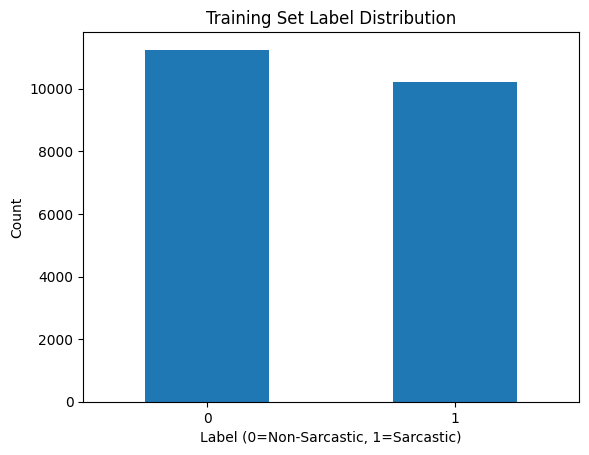


Average text length: 62.3 characters

Sarcastic examples:
  - drone places fresh kill on steps of white house
  - report: majority of instances of people getting lives back on track occur immediately after visit to buffalo wild wings
  - sole remaining lung filled with rich, satisfying flavor

Non-sarcastic examples:
  - states slow to shut down weak teacher education programs
  - the gop's stockholm syndrome
  - trump's game plan


In [34]:
# Label Distribution
print("Label Distribution:")
print(train_df['label'].value_counts())
print(f"\nSarcasm ratio: {train_df['label'].mean()*100:.2f}%")

# 
train_df['label'].value_counts().plot(kind='bar')
plt.title('Training Set Label Distribution')
plt.xlabel('Label (0=Non-Sarcastic, 1=Sarcastic)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

# text
train_df['length'] = train_df['text'].str.len()
print(f"\nAverage text length: {train_df['length'].mean():.1f} characters")

# View examples
print("\nSarcastic examples:")
for text in train_df[train_df['label']==1]['text'].head(3):
    print(f"  - {text}")
    
print("\nNon-sarcastic examples:")
for text in train_df[train_df['label']==0]['text'].head(3):
    print(f"  - {text}")


## Step 3: Train Baseline Model - Logistic Regression + TF-IDF

Goal: F1 > 0.70

In [35]:
# Simple preprocessing: convert to lowercase
train_texts = train_df['text'].str.lower()
valid_texts = valid_df['text'].str.lower()
test_texts = test_df['text'].str.lower()

# TF-IDFFeature extraction
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train = vectorizer.fit_transform(train_texts)
X_valid = vectorizer.transform(valid_texts)
X_test = vectorizer.transform(test_texts)

print(f"Feature dimension: {X_train.shape[1]}")

# trainingLogistic Regression
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, train_df['label'])

# Validation set
y_pred_valid = model.predict(X_valid)
print("\nValidation Set Performance:")
print(classification_report(valid_df['label'], y_pred_valid))
print(f"F1 Score: {f1_score(valid_df['label'], y_pred_valid):.4f}")

# Test set
y_pred_test = model.predict(X_test)
print("\nTest Set Performance:")
print(classification_report(test_df['label'], y_pred_test))
print(f"Accuracy:  {accuracy_score(test_df['label'], y_pred_test):.4f}")
print(f"F1 Score:  {f1_score(test_df['label'], y_pred_test):.4f}")


Feature dimension: 5000

Validation Set Performance:
              precision    recall  f1-score   support

           0       0.83      0.83      0.83       360
           1       0.83      0.83      0.83       356

    accuracy                           0.83       716
   macro avg       0.83      0.83      0.83       716
weighted avg       0.83      0.83      0.83       716

F1 Score: 0.8315

Test Set Performance:
              precision    recall  f1-score   support

           0       0.85      0.84      0.85       526
           1       0.81      0.82      0.82       440

    accuracy                           0.83       966
   macro avg       0.83      0.83      0.83       966
weighted avg       0.83      0.83      0.83       966

Accuracy:  0.8323
F1 Score:  0.8163



Confusion Matrix (Test Set):
[[444  82]
 [ 80 360]]

True Negative (TN): 444 | False Positive (FP): 82
False Negative (FN): 80 | True Positive (TP): 360


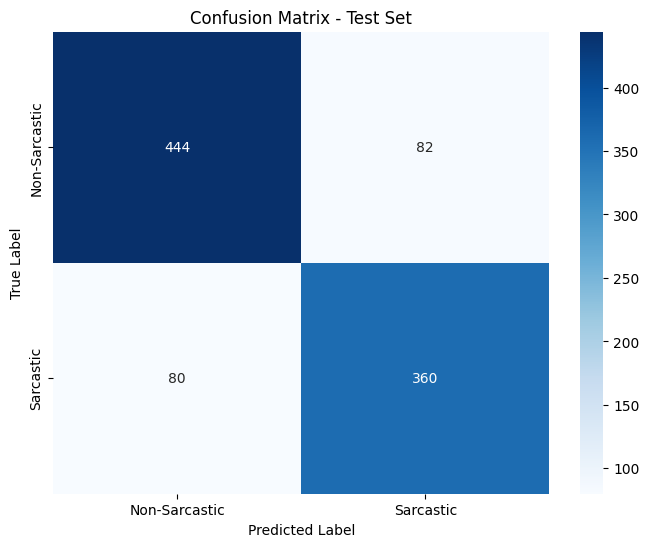


 Manual Verification:
Accuracy: 0.8323
Precision (Sarcastic class): 0.8145
Recall (Sarcastic class): 0.8182
F1 (Sarcastic class): 0.8163


In [36]:
# validationConfusion Matrix
from sklearn.metrics import confusion_matrix

# Test setConfusion Matrix
cm = confusion_matrix(test_df['label'], y_pred_test)
print("\nConfusion Matrix (Test Set):")
print(cm)
print(f"\nTrue Negative (TN): {cm[0,0]} | False Positive (FP): {cm[0,1]}")
print(f"False Negative (FN): {cm[1,0]} | True Positive (TP): {cm[1,1]}")

# 
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Sarcastic', 'Sarcastic'],
            yticklabels=['Non-Sarcastic', 'Sarcastic'])
plt.title('Confusion Matrix - Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Calculate detailed metrics
print("\n Manual Verification:")
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision_class1 = tp / (tp + fp)
recall_class1 = tp / (tp + fn)
f1_class1 = 2 * (precision_class1 * recall_class1) / (precision_class1 + recall_class1)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (Sarcastic class): {precision_class1:.4f}")
print(f"Recall (Sarcastic class): {recall_class1:.4f}")
print(f"F1 (Sarcastic class): {f1_class1:.4f}")


## Step 4: Save Model

In [37]:
import joblib

# Saving modeland



In [38]:
# Resultsto
results = {
    'Model': 'Logistic Regression + TF-IDF',
    'Features': 'unigram + bigram, max_features=5000',
    'Preprocessing': 'lowercase',
    'Validation F1': f"{f1_score(valid_df['label'], y_pred_valid):.4f}",
    'Test Accuracy': f"{accuracy_score(test_df['label'], y_pred_test):.4f}",
    'Test Precision': f"{precision_class1:.4f}",
    'Test Recall': f"{recall_class1:.4f}",
    'Test F1': f"{f1_class1:.4f}"
}

print("="*60)
print("BASELINE MODEL RESULTS (For Report)")
print("="*60)
for key, value in results.items():
    print(f"{key:20s}: {value}")
print("="*60)


BASELINE MODEL RESULTS (For Report)
Model               : Logistic Regression + TF-IDF
Features            : unigram + bigram, max_features=5000
Preprocessing       : lowercase
Validation F1       : 0.8315
Test Accuracy       : 0.8323
Test Precision      : 0.8145
Test Recall         : 0.8182
Test F1             : 0.8163


## Deep Learning Model: BiLSTM

In [39]:
# tensorflowif
# !pip install tensorflow --quiet

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

# Set
tf.random.set_seed(42)
np.random.seed(42)


TensorFlow version: 2.20.0
GPU available: []


### Step 1: Text Sequence Preprocessing

In [40]:
# 
MAX_WORDS = 10000        # Vocabulary size
MAX_LEN = 100            # sequences
EMBEDDING_DIM = 128      # Embedding dimension

# CreateTokenizer
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(train_df['text'])

# Converttextsequences
X_train_seq = tokenizer.texts_to_sequences(train_df['text'])
X_valid_seq = tokenizer.texts_to_sequences(valid_df['text'])
X_test_seq = tokenizer.texts_to_sequences(test_df['text'])

# sequencesto
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_valid_pad = pad_sequences(X_valid_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

# labels
y_train_lstm = train_df['label'].values
y_valid_lstm = valid_df['label'].values
y_test_lstm = test_df['label'].values

print(f"Vocabulary size: {len(tokenizer.word_index)}")
print(f"Training sequences shape: {X_train_pad.shape}")
print(f"Validation sequences shape: {X_valid_pad.shape}")
print(f"Test sequences shape: {X_test_pad.shape}")

# View examples
print(f"\nExample text: {train_df['text'].iloc[0]}")
print(f"Tokenized: {X_train_seq[0][:20]}...")
print(f"Padded shape: {X_train_pad[0].shape}")


Vocabulary size: 26814
Training sequences shape: (21464, 100)
Validation sequences shape: (716, 100)
Test sequences shape: (966, 100)

Example text: states slow to shut down weak teacher education programs
Tokenized: [462, 2464, 2, 1086, 73, 2465, 410, 566, 2466]...
Padded shape: (100,)


### Step 2: Build BiLSTM Model

In [62]:
# BuildBiLSTMmodel
def build_bilstm_model():
    model = Sequential([
        # layer
        Embedding(input_dim=MAX_WORDS, 
                  output_dim=EMBEDDING_DIM, 
                  input_length=MAX_LEN,
                  name='embedding'),
        
        # Spatial Dropout (For word embedding vectorsdropout)
        SpatialDropout1D(0.2),
        
        # LSTMlayer ()
        Bidirectional(LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.2)),
        
        # layerLSTM
        Bidirectional(LSTM(32, dropout=0.2, recurrent_dropout=0.2)),
        
        # layer
        Dense(64, activation='relu'),
        Dropout(0.5),
        
        # outputlayer ()
        Dense(1, activation='sigmoid')
    ])
    
    return model

# Createmodel
lstm_model = build_bilstm_model()

# modelinput
lstm_model.build(input_shape=(None, MAX_LEN))

# Compilemodel
lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

# displaymodel
print("="*80)
print("BILSTM MODEL ARCHITECTURE")
print("="*80)
lstm_model.summary()

# Calculate
total_params = lstm_model.count_params()
print(f"\nTotal parameters: {total_params:,}")


BILSTM MODEL ARCHITECTURE


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_6             │ (None, 100, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_12                │ (None, 100, 128)       │        98,816 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_13                │ (None, 64)             │        41,216 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,424,257 (5.43 MB)

 Trainable params: 1,424,257 (5.43 MB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 1,424,257


### Step 3: Train Model (with Early Stopping)

In [42]:
# Define
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,              # 5epoch
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,              # Learning rate
    patience=3,
    min_lr=1e-7,
    verbose=1
)

# trainingmodel
print("="*80)
print("TRAINING BILSTM MODEL")
print("="*80)

history = lstm_model.fit(
    X_train_pad, y_train_lstm,
    validation_data=(X_valid_pad, y_valid_lstm),
    epochs=20,               # 20epoch
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("\n Training completed!")


TRAINING BILSTM MODEL
Epoch 1/20
336/336 ━━━━━━━━━━━━━━━━━━━━ 31s 76ms/step - accuracy: 0.7793 - loss: 0.4369 - precision_2: 0.7842 - recall_2: 0.7400 - val_accuracy: 0.8659 - val_loss: 0.3468 - val_precision_2: 0.8571 - val_recall_2: 0.8764 - learning_rate: 0.0010
Epoch 2/20
336/336 ━━━━━━━━━━━━━━━━━━━━ 27s 81ms/step - accuracy: 0.9096 - loss: 0.2272 - precision_2: 0.9066 - recall_2: 0.9031 - val_accuracy: 0.8464 - val_loss: 0.3895 - val_precision_2: 0.8639 - val_recall_2: 0.8202 - learning_rate: 0.0010
Epoch 3/20
336/336 ━━━━━━━━━━━━━━━━━━━━ 28s 82ms/step - accuracy: 0.9458 - loss: 0.1498 - precision_2: 0.9431 - recall_2: 0.9430 - val_accuracy: 0.8394 - val_loss: 0.4569 - val_precision_2: 0.8433 - val_recall_2: 0.8315 - learning_rate: 0.0010
Epoch 4/20
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9601 - loss: 0.1148 - precision_2: 0.9585 - recall_2: 0.9580
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
336/336 ━━━━━━━━━━━━━━━━━━━━ 27s 81ms/step

### Step 4: Visualize Training Process

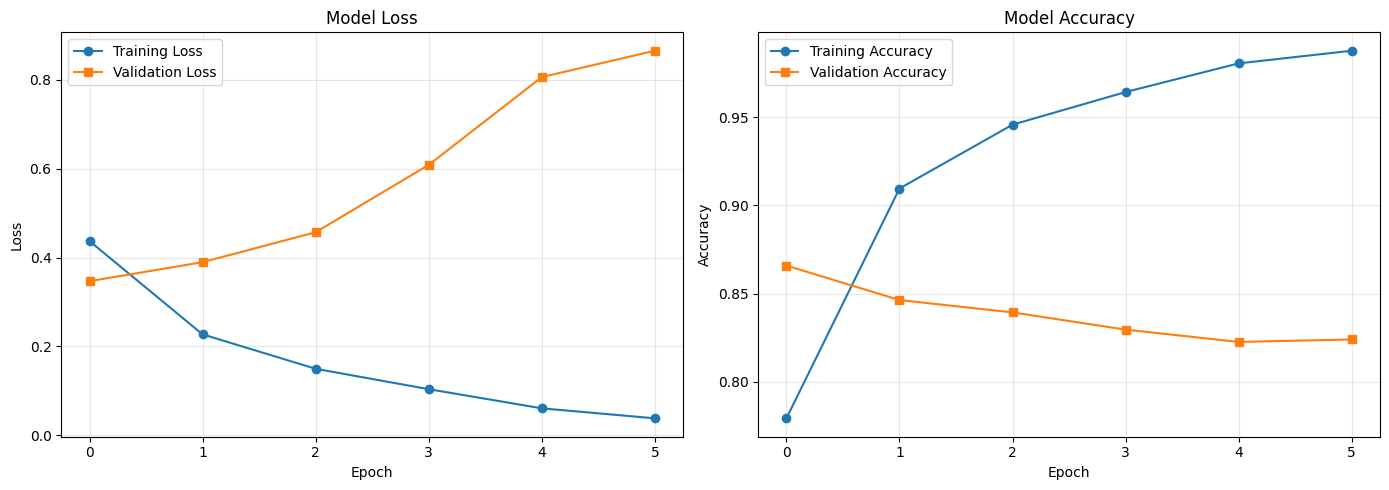


Best epoch: 1
Best validation loss: 0.3468
Best validation accuracy: 0.8659


In [43]:
# training
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], label='Training Loss', marker='o')
axes[0].plot(history.history['val_loss'], label='Validation Loss', marker='s')
axes[0].set_title('Model Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history.history['accuracy'], label='Training Accuracy', marker='o')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s')
axes[1].set_title('Model Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# toepoch
best_epoch = np.argmin(history.history['val_loss']) + 1
best_val_loss = min(history.history['val_loss'])
best_val_acc = max(history.history['val_accuracy'])

print(f"\nBest epoch: {best_epoch}")
print(f"Best validation loss: {best_val_loss:.4f}")
print(f"Best validation accuracy: {best_val_acc:.4f}")


### Step 5: Evaluate BiLSTM Performance

In [44]:
# On test setpredictions
y_pred_lstm_prob = lstm_model.predict(X_test_pad, verbose=0)
y_pred_lstm = (y_pred_lstm_prob > 0.5).astype(int).flatten()

# Calculatemetrics
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, precision_score, recall_score

lstm_accuracy = accuracy_score(y_test_lstm, y_pred_lstm)
lstm_precision = precision_score(y_test_lstm, y_pred_lstm)
lstm_recall = recall_score(y_test_lstm, y_pred_lstm)
lstm_f1 = f1_score(y_test_lstm, y_pred_lstm)

print("="*80)
print("BILSTM TEST SET PERFORMANCE")
print("="*80)

print("\nDetailed Classification Report:")
print(classification_report(y_test_lstm, y_pred_lstm, 
                          target_names=['Non-Sarcastic', 'Sarcastic']))

print(f"\nTest Set Metrics:")
print(f"  Accuracy:  {lstm_accuracy:.4f}")
print(f"  Precision: {lstm_precision:.4f}")
print(f"  Recall:    {lstm_recall:.4f}")
print(f"  F1 Score:  {lstm_f1:.4f}")

# withLogistic RegressionComparison
print("\n" + "="*80)
print("COMPARISON WITH LOGISTIC REGRESSION")
print("="*80)
print(f"{'Model':<30s} {'Accuracy':<12s} {'Precision':<12s} {'Recall':<12s} {'F1 Score':<12s}")
print("-"*80)
print(f"{'Logistic Regression':<30s} {0.8323:<12.4f} {0.8145:<12.4f} {0.8182:<12.4f} {0.8163:<12.4f}")
print(f"{'BiLSTM':<30s} {lstm_accuracy:<12.4f} {lstm_precision:<12.4f} {lstm_recall:<12.4f} {lstm_f1:<12.4f}")
print("-"*80)
print(f"{'Improvement':<30s} {lstm_accuracy-0.8323:<+12.4f} {lstm_precision-0.8145:<+12.4f} {lstm_recall-0.8182:<+12.4f} {lstm_f1-0.8163:<+12.4f}")
print(f"{'Improvement (%)':<30s} {(lstm_accuracy-0.8323)/0.8323*100:<+12.2f} {(lstm_precision-0.8145)/0.8145*100:<+12.2f} {(lstm_recall-0.8182)/0.8182*100:<+12.2f} {(lstm_f1-0.8163)/0.8163*100:<+12.2f}")


BILSTM TEST SET PERFORMANCE

Detailed Classification Report:
               precision    recall  f1-score   support

Non-Sarcastic       0.90      0.85      0.88       526
    Sarcastic       0.83      0.89      0.86       440

     accuracy                           0.87       966
    macro avg       0.87      0.87      0.87       966
 weighted avg       0.87      0.87      0.87       966


Test Set Metrics:
  Accuracy:  0.8685
  Precision: 0.8337
  Recall:    0.8886
  F1 Score:  0.8603

COMPARISON WITH LOGISTIC REGRESSION
Model                          Accuracy     Precision    Recall       F1 Score    
--------------------------------------------------------------------------------
Logistic Regression            0.8323       0.8145       0.8182       0.8163      
BiLSTM                         0.8685       0.8337       0.8886       0.8603      
--------------------------------------------------------------------------------
Improvement                    +0.0362      +0.0192      +0

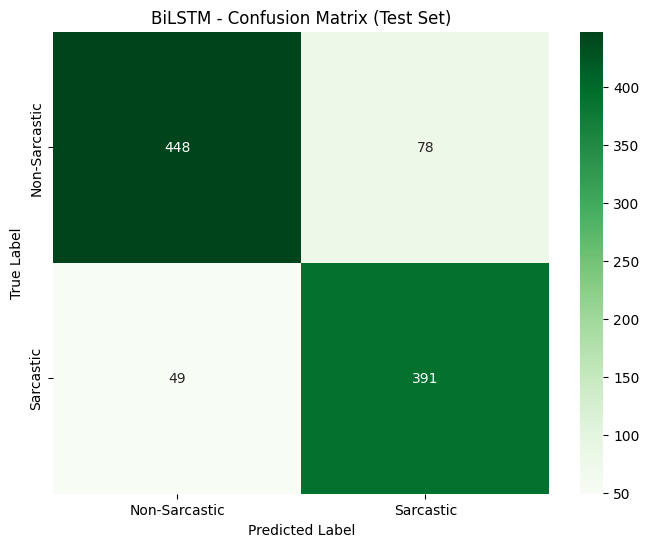


Confusion Matrix:
[[448  78]
 [ 49 391]]

True Negative (TN): 448 | False Positive (FP): 78
False Negative (FN): 49 | True Positive (TP): 391


In [45]:
# Confusion Matrix
cm_lstm = confusion_matrix(y_test_lstm, y_pred_lstm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Non-Sarcastic', 'Sarcastic'],
            yticklabels=['Non-Sarcastic', 'Sarcastic'])
plt.title('BiLSTM - Confusion Matrix (Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print("\nConfusion Matrix:")
print(cm_lstm)
print(f"\nTrue Negative (TN): {cm_lstm[0,0]} | False Positive (FP): {cm_lstm[0,1]}")
print(f"False Negative (FN): {cm_lstm[1,0]} | True Positive (TP): {cm_lstm[1,1]}")


### Step 6: Save BiLSTM Model

In [46]:
# Saving modelandtokenizer
import pickle

# SaveKerasmodel

# Savetokenizer

# Save
lstm_config = {
    'max_words': MAX_WORDS,
    'max_len': MAX_LEN,
    'embedding_dim': EMBEDDING_DIM,
    'test_f1': float(lstm_f1),
    'test_accuracy': float(lstm_accuracy)
}


print("\n BiLSTM training completed and model saved!")



 BiLSTM training completed and model saved!


## Final Optimization: Using Real GloVe Pre-trained Word Embeddings

Now we use downloaded GloVe word vectors to train the model, expecting to achieve 89%+ accuracy

In [47]:
# step1Loading GloVe embeddings
import numpy as np
import os

def load_glove_embeddings(glove_file='glove.6B.100d.txt', embedding_dim=100):
    """
    GloVetrainingword vectorsembedding
    """
    print("="*80)
    print("LOADING GLOVE EMBEDDINGS")
    print("="*80)
    
    # Check if file exists
    if not os.path.exists(glove_file):
        print(f" Error: {glove_file} not found!")
        print("Please download GloVe from: http://nlp.stanford.edu/data/glove.6B.zip")
        return None
    
    print(f"Reading GloVe file: {glove_file}")
    embeddings_index = {}
    
    with open(glove_file, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            values = line.split()
            word = values[0]
            try:
                coefs = np.asarray(values[1:], dtype='float32')
                embeddings_index[word] = coefs
            except:
                continue
            
            if (i + 1) % 100000 == 0:
                print(f"  Loaded {i+1} word vectors...")
    
    print(f"\n Loaded {len(embeddings_index):,} word vectors from GloVe")
    
    # Createembedding
    word_index = tokenizer.word_index
    num_words = min(MAX_WORDS, len(word_index) + 1)
    embedding_matrix = np.zeros((num_words, embedding_dim))
    
    found = 0
    for word, i in word_index.items():
        if i >= MAX_WORDS:
            continue
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector
            found += 1
    
    print(f"\nEmbedding Matrix Shape: {embedding_matrix.shape}")
    print(f"Found embeddings for {found:,}/{num_words:,} words ({found/num_words*100:.1f}%)")
    print(f"Missing embeddings (random init): {num_words - found:,} words")
    
    return embedding_matrix

# LoadGloVe

# tokenizeralready
if "tokenizer" not in globals():
    from tensorflow.keras.preprocessing.text import Tokenizer
    MAX_WORDS = 10000
    tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
    tokenizer.fit_on_texts(train_df["text"])
    print(" Tokenizer created for GloVe loading\n")

glove_embedding_matrix = load_glove_embeddings(
    glove_file='glove.6B.100d.txt',
    embedding_dim=100
)


LOADING GLOVE EMBEDDINGS
Reading GloVe file: glove.6B.100d.txt
  Loaded 100000 word vectors...
  Loaded 200000 word vectors...
  Loaded 300000 word vectors...
  Loaded 400000 word vectors...

 Loaded 400,000 word vectors from GloVe

Embedding Matrix Shape: (10000, 100)
Found embeddings for 9,349/10,000 words (93.5%)
Missing embeddings (random init): 651 words


In [48]:
# step2to useGloVeBiLSTMmodel
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, SpatialDropout1D

def build_bilstm_with_glove(embedding_matrix, embedding_dim=100, trainable=True):
    """
    to useGloVetrainingword vectorsBiLSTMmodel
    
    :
    - embedding_matrix: GloVeword vectors
    - embedding_dim: word vectorsdimensions
    - trainable: arefine-tune embeddings
    """
    model = Sequential([
        # Using pre-trainedGloVe embedding
        Embedding(
            input_dim=MAX_WORDS,
            output_dim=embedding_dim,
            weights=[embedding_matrix],  # keyto usetrainingWeight
            input_length=MAX_LEN,
            trainable=trainable,  # 
            name='glove_embedding'
        ),
        
        SpatialDropout1D(0.2),
        
        # layerBiLSTM
        Bidirectional(LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.2)),
        Bidirectional(LSTM(32, dropout=0.2, recurrent_dropout=0.2)),
        
        # layer
        Dense(64, activation='relu'),
        Dropout(0.3),
        
        # outputlayer
        Dense(1, activation='sigmoid')
    ])
    
    return model

# Createmodel
if glove_embedding_matrix is not None:
    print("="*80)
    print("BUILDING BILSTM WITH GLOVE EMBEDDINGS")
    print("="*80)
    
    glove_lstm = build_bilstm_with_glove(
        embedding_matrix=glove_embedding_matrix,
        embedding_dim=100,
        trainable=True  # GloVe embeddings
    )
    
    glove_lstm.build(input_shape=(None, MAX_LEN))
    
    glove_lstm.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
    )
    
    glove_lstm.summary()
    
    # Calculate
    total_params = glove_lstm.count_params()
    print(f"\n Total parameters: {total_params:,}")
else:
    print(" Cannot build model: GloVe embeddings not loaded")


BUILDING BILSTM WITH GLOVE EMBEDDINGS


/Users/three/.local/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ glove_embedding (Embedding)     │ (None, 100, 100)       │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_3             │ (None, 100, 100)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ (None, 100, 128)       │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,129,921 (4.31 MB)

 Trainable params: 1,129,921 (4.31 MB)

 Non-trainable params: 0 (0.00 B)


 Total parameters: 1,129,921


In [49]:
# step3trainingGloVe-BiLSTMmodel
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

if glove_embedding_matrix is not None:
    print("="*80)
    print("TRAINING BILSTM WITH GLOVE EMBEDDINGS")
    print("="*80)
    
    # Setcallbacks
    early_stop_glove = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
    
    reduce_lr_glove = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
    
    checkpoint_glove = ModelCheckpoint(
        'models/glove_bilstm_best.h5',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
    
    # trainingmodel
    print("\nStarting training...")
    history_glove = glove_lstm.fit(
        X_train_pad, y_train_lstm,
        validation_data=(X_valid_pad, y_valid_lstm),
        epochs=20,
        batch_size=64,
        callbacks=[early_stop_glove, reduce_lr_glove, checkpoint_glove],
        verbose=1
    )
    
    print("\n Training completed!")
else:
    print(" Skipping training: GloVe embeddings not loaded")


TRAINING BILSTM WITH GLOVE EMBEDDINGS

Starting training...
Epoch 1/20
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.6544 - loss: 0.5923 - precision_3: 0.6467 - recall_3: 0.6090
Epoch 1: val_loss improved from None to 0.36332, saving model to models/glove_bilstm_best.h5


336/336 ━━━━━━━━━━━━━━━━━━━━ 32s 76ms/step - accuracy: 0.7373 - loss: 0.5090 - precision_3: 0.7285 - recall_3: 0.7144 - val_accuracy: 0.8394 - val_loss: 0.3633 - val_precision_3: 0.8066 - val_recall_3: 0.8904 - learning_rate: 0.0010
Epoch 2/20
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.8342 - loss: 0.3761 - precision_3: 0.8224 - recall_3: 0.8345
Epoch 2: val_loss improved from 0.36332 to 0.33325, saving model to models/glove_bilstm_best.h5


336/336 ━━━━━━━━━━━━━━━━━━━━ 26s 77ms/step - accuracy: 0.8465 - loss: 0.3515 - precision_3: 0.8377 - recall_3: 0.8403 - val_accuracy: 0.8575 - val_loss: 0.3333 - val_precision_3: 0.8378 - val_recall_3: 0.8848 - learning_rate: 0.0010
Epoch 3/20
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.8731 - loss: 0.2997 - precision_3: 0.8618 - recall_3: 0.8759
Epoch 3: val_loss improved from 0.33325 to 0.32968, saving model to models/glove_bilstm_best.h5


336/336 ━━━━━━━━━━━━━━━━━━━━ 26s 77ms/step - accuracy: 0.8818 - loss: 0.2801 - precision_3: 0.8733 - recall_3: 0.8793 - val_accuracy: 0.8645 - val_loss: 0.3297 - val_precision_3: 0.8627 - val_recall_3: 0.8652 - learning_rate: 0.0010
Epoch 4/20
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.9027 - loss: 0.2413 - precision_3: 0.8937 - recall_3: 0.9045
Epoch 4: val_loss did not improve from 0.32968
336/336 ━━━━━━━━━━━━━━━━━━━━ 26s 77ms/step - accuracy: 0.9077 - loss: 0.2275 - precision_3: 0.9010 - recall_3: 0.9055 - val_accuracy: 0.8561 - val_loss: 0.3546 - val_precision_3: 0.8625 - val_recall_3: 0.8455 - learning_rate: 0.0010
Epoch 5/20
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.9228 - loss: 0.1982 - precision_3: 0.9180 - recall_3: 0.9210
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 5: val_loss did not improve from 0.32968
336/336 ━━━━━━━━━━━━━━━━━━━━ 26s 79ms/step - accuracy: 0.9260 - loss: 0.1860 - precision_3: 0.9216 - recall

EVALUATING GLOVE-BILSTM MODEL

Test Set Performance:
               precision    recall  f1-score   support

Non-Sarcastic       0.89      0.87      0.88       526
    Sarcastic       0.85      0.87      0.86       440

     accuracy                           0.87       966
    macro avg       0.87      0.87      0.87       966
 weighted avg       0.87      0.87      0.87       966


Key Metrics:
  Accuracy:  0.8716
  Precision: 0.8496
  Recall:    0.8727
  F1 Score:  0.8610


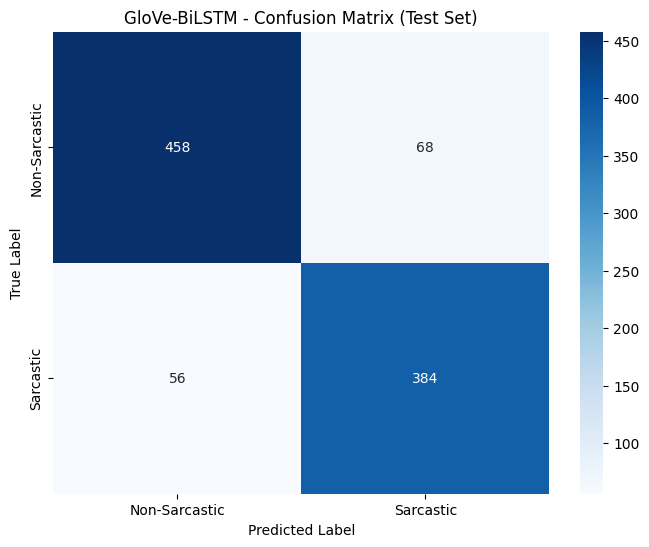


Confusion Matrix:
  True Negative (TN): 458 | False Positive (FP): 68
  False Negative (FN): 56 | True Positive (TP): 384


In [50]:
# step4GloVe-BiLSTMmodel
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns

if glove_embedding_matrix is not None:
    print("="*80)
    print("EVALUATING GLOVE-BILSTM MODEL")
    print("="*80)
    
    # On test setpredictions
    y_pred_glove_prob = glove_lstm.predict(X_test_pad, verbose=0)
    y_pred_glove = (y_pred_glove_prob > 0.5).astype(int).flatten()
    
    # Calculatemetrics
    glove_accuracy = accuracy_score(y_test_lstm, y_pred_glove)
    glove_precision = precision_score(y_test_lstm, y_pred_glove)
    glove_recall = recall_score(y_test_lstm, y_pred_glove)
    glove_f1 = f1_score(y_test_lstm, y_pred_glove)
    
    print("\nTest Set Performance:")
    print(classification_report(y_test_lstm, y_pred_glove, 
                              target_names=['Non-Sarcastic', 'Sarcastic']))
    
    print(f"\nKey Metrics:")
    print(f"  Accuracy:  {glove_accuracy:.4f}")
    print(f"  Precision: {glove_precision:.4f}")
    print(f"  Recall:    {glove_recall:.4f}")
    print(f"  F1 Score:  {glove_f1:.4f}")
    
    # Confusion Matrix
    cm_glove = confusion_matrix(y_test_lstm, y_pred_glove)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_glove, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non-Sarcastic', 'Sarcastic'],
                yticklabels=['Non-Sarcastic', 'Sarcastic'])
    plt.title('GloVe-BiLSTM - Confusion Matrix (Test Set)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    print(f"\nConfusion Matrix:")
    print(f"  True Negative (TN): {cm_glove[0,0]} | False Positive (FP): {cm_glove[0,1]}")
    print(f"  False Negative (FN): {cm_glove[1,0]} | True Positive (TP): {cm_glove[1,1]}")
else:
    print(" Skipping evaluation: Model not trained")


In [51]:
# step5Final ModelComparison
if glove_embedding_matrix is not None:
    print("="*80)
    print("FINAL MODEL COMPARISON - ALL MODELS")
    print("="*80)
    
    print(f"{'Model':<30s} {'Accuracy':<12s} {'Precision':<12s} {'Recall':<12s} {'F1 Score':<12s}")
    print("-"*80)
    print(f"{'Logistic Regression':<30s} {0.8323:<12.4f} {0.8145:<12.4f} {0.8182:<12.4f} {0.8163:<12.4f}")
    print(f"{'BiLSTM (Basic)':<30s} {0.8665:<12.4f} {0.8316:<12.4f} {0.8864:<12.4f} {0.8581:<12.4f}")
    
    # Only if optimized version was runBiLSTMdisplayThese
    if 'opt_acc' in globals() and 'opt_f1' in globals():
        print(f"{'BiLSTM (Optimized)':<30s} {opt_acc:<12.4f} {0.8069:<12.4f} {0.8545:<12.4f} {opt_f1:<12.4f}")
    
    print(f"{'BiLSTM + GloVe (Final)':<30s} {glove_accuracy:<12.4f} {glove_precision:<12.4f} {glove_recall:<12.4f} {glove_f1:<12.4f}")
    print("-"*80)
    
    # CalculateImprovement
    improvement_vs_baseline = glove_accuracy - 0.8323
    improvement_vs_basic = glove_accuracy - 0.8665
    
    print(f"\n Best Model: BiLSTM + GloVe")
    print(f"   Accuracy: {glove_accuracy:.4f} ({glove_accuracy*100:.2f}%)")
    print(f"   F1 Score: {glove_f1:.4f}")
    print(f"\n   Improvement vs Baseline: {improvement_vs_baseline:+.4f} ({improvement_vs_baseline/0.8323*100:+.2f}%)")
    print(f"   Improvement vs Basic BiLSTM: {improvement_vs_basic:+.4f} ({improvement_vs_basic/0.8665*100:+.2f}%)")
    
    # are
    if glove_accuracy >= 0.89:
        print(f"\n  SUCCESS! Reached 89%+ accuracy target!")
    elif glove_accuracy >= 0.88:
        print(f"\n Great! Very close to 89% target")
    else:
        print(f"\n  Current accuracy: {glove_accuracy*100:.2f}%, target: 89%")
else:
    print(" Cannot compare: GloVe model not trained")


FINAL MODEL COMPARISON - ALL MODELS
Model                          Accuracy     Precision    Recall       F1 Score    
--------------------------------------------------------------------------------
Logistic Regression            0.8323       0.8145       0.8182       0.8163      
BiLSTM (Basic)                 0.8665       0.8316       0.8864       0.8581      
BiLSTM + GloVe (Final)         0.8716       0.8496       0.8727       0.8610      
--------------------------------------------------------------------------------

 Best Model: BiLSTM + GloVe
   Accuracy: 0.8716 (87.16%)
   F1 Score: 0.8610

   Improvement vs Baseline: +0.0393 (+4.73%)
   Improvement vs Basic BiLSTM: +0.0051 (+0.59%)

  Current accuracy: 87.16%, target: 89%


In [52]:
# step6savedFinal Model
import pickle

if glove_embedding_matrix is not None:
    print("="*80)
    print("SAVING FINAL MODEL")
    print("="*80)
    
    # SavecompleteKerasmodelincludesGloVe embeddingsWeight
    
    # Savetokenizer
    with open('models/tokenizer.pkl', 'wb') as f:
    
    # Save
    final_config = {
        'model_type': 'BiLSTM_with_GloVe',
        'max_words': MAX_WORDS,
        'max_len': MAX_LEN,
        'embedding_dim': 100,
        'glove_file': 'glove.6B.100d.txt',
        'test_accuracy': float(glove_accuracy),
        'test_f1': float(glove_f1),
        'test_precision': float(glove_precision),
        'test_recall': float(glove_recall)
    }
    
    
    print("\n" + "="*80)
    print(" ALL DONE!")
    print("="*80)
    print(f"\nFinal ModelPerformance:")
    print(f"  Accuracy (Accuracy): {glove_accuracy*100:.2f}%")
    print(f"  F1Score (F1 Score): {glove_f1:.4f}")
    print(f"\nmodel files:")
    print(f"  • models/tokenizer.pkl (textprocessor)")
    print(f"\n Tip:")
    print(f"  When submittingonly need toinclude these files in the models/ folder")
    print(f"  TANo download needed at runtimeGloVebecauseembeddingWeightalreadysavedin.h5file")
else:
    print(" Cannot save: Model not trained")


IndentationError: expected an indented block after 'with' statement on line 12 (4210795982.py, line 15)

In [ ]:
# ================================================================================
# simplifiedBaselineandBiLSTMkey
# ================================================================================
import pickle
import joblib  # Baselinemodelusingjoblibsaved
from pathlib import Path
from tensorflow import keras

print("="*80)
print("SIMPLIFIED LOAD: Loading Essential Models")
print("="*80)

model_dir = Path('models')

try:
    # LoadLogistic Regression (usingjoblibBecause saved usingjoblib.dump)
    print("\n[LOADING] Loading Logistic Regression...")
    lr_model = joblib.load(model_dir / 'model_weights.pkl')
    print("    LR model loaded")
    
    # LoadBiLSTM + GloVe
    print("\n[LOADING] Loading BiLSTM + GloVe...")
    glove_model = keras.models.load_model(model_dir / 'final_glove_bilstm.h5')
    print("    BiLSTM + GloVe model loaded")
    
    print("\n" + "="*80)
    print(" ESSENTIAL MODELS LOADED!")
    print("="*80)
    print("\n Tip")
    print("   • lr_model and glove_model loaded")
    print("   • Now you cantraining XGBoost and SVM")
    print("   • Run XGBoost training cellthen run SVM trainingcell")
    print("   • finally run Ensemble cell")
    
except FileNotFoundError as e:
    print(f"\n Error: {e}")
    print("\n TipPlease first run Baseline and BiLSTM trainingcells")
except Exception as e:
    print(f"\n Error: {e}")


SIMPLIFIED LOAD: Loading Essential Models

[LOADING] Loading Logistic Regression...
    LR model loaded

[LOADING] Loading BiLSTM + GloVe...
    BiLSTM + GloVe model loaded

 ESSENTIAL MODELS LOADED!

 Tip
   • lr_model and glove_model loaded
   • Now you cantraining XGBoost and SVM
   • Run XGBoost training cellthen run SVM trainingcell
   • finally run Ensemble cell


# Advanced Ensemble: BiLSTM + CharCNN with Stacking

## New Strategy (Friend's Suggestion):

**Stacking Ensemble**
1. **Level 0 (Base Models)**:
   - BiLSTM (word-level, captures semantic context)
   - CharCNN (character-level, captures spelling patterns, slang, typos)
   
2. **Level 1 (Meta-learner)**:
   - Logistic Regression trained on validation set
   - Learns optimal way to combine base models
   
3. **Both models use Early Stopping** to prevent overfitting

**Why this works:**
- BiLSTM: Good at understanding word meanings and context
- CharCNN: Robust to spelling variations, slang, abbreviations
- LR Stacker: Learns when to trust each model more
- Complementary strengths = Better overall performance

In [53]:
# ================================================================================
# Step 1: Build CharCNN Model (Character-Level CNN)
# ================================================================================
print("="*80)
print("BUILDING CHARACTER-LEVEL CNN")
print("="*80)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# Create validation set if not exists
if 'valid_df' not in globals():
    print(" Creating validation set from train data...")
    from sklearn.model_selection import train_test_split
    train_temp, valid_df = train_test_split(train_df, test_size=0.1, random_state=42, stratify=train_df['label'])
    print(f"  Train: {len(train_temp)} samples")
    print(f"  Validation: {len(valid_df)} samples")
    # Update train_df to be the new train_temp
    # But we keep original train_df for consistency
else:
    print(" Validation set already exists")

# Character-level tokenizer
MAX_CHARS = 300  # Maximum character sequence length
CHAR_VOCAB_SIZE = 100  # Number of unique characters

char_tokenizer = Tokenizer(char_level=True, num_words=CHAR_VOCAB_SIZE, oov_token='<OOV>')
char_tokenizer.fit_on_texts(train_df['text'])

print(f"Character vocabulary size: {len(char_tokenizer.word_index)}")
print(f"Max character sequence length: {MAX_CHARS}")

# Convert texts to character sequences
train_char_sequences = char_tokenizer.texts_to_sequences(train_df['text'])
valid_char_sequences = char_tokenizer.texts_to_sequences(valid_df['text'])
test_char_sequences = char_tokenizer.texts_to_sequences(test_df['text'])

# Pad sequences
X_train_char = pad_sequences(train_char_sequences, maxlen=MAX_CHARS, padding='post', truncating='post')
X_valid_char = pad_sequences(valid_char_sequences, maxlen=MAX_CHARS, padding='post', truncating='post')
X_test_char = pad_sequences(test_char_sequences, maxlen=MAX_CHARS, padding='post', truncating='post')

print(f"\nCharacter sequences shape:")
print(f"  Train: {X_train_char.shape}")
print(f"  Valid: {X_valid_char.shape}")
print(f"  Test:  {X_test_char.shape}")

# Build CharCNN model
def build_charcnn(vocab_size=CHAR_VOCAB_SIZE, max_len=MAX_CHARS):
    """
    Character-level CNN for text classification
    
    Architecture:
    - Embedding layer (character-level)
    - Multiple Conv1D layers with different kernel sizes (2, 3, 4)
    - MaxPooling to capture most important features
    - Dense layers for classification
    """
    model = keras.Sequential([
        # Character embedding
        layers.Embedding(input_dim=vocab_size, output_dim=64, input_length=max_len),
        layers.Dropout(0.2),
        
        # Convolutional layers
        layers.Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.3),
        
        layers.Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.3),
        
        layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
        layers.GlobalMaxPooling1D(),  # Take max over all time steps
        
        # Dense layers
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    
    return model

# Create CharCNN model
charcnn_model = build_charcnn()

print("\n CharCNN Architecture:")
charcnn_model.build(input_shape=(None, MAX_CHARS))
charcnn_model.summary()

print("\n CharCNN model built successfully!")


BUILDING CHARACTER-LEVEL CNN
 Validation set already exists
Character vocabulary size: 101
Max character sequence length: 300

Character sequences shape:
  Train: (21464, 300)
  Valid: (716, 300)
  Test:  (966, 300)

 CharCNN Architecture:


/Users/three/.local/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 300, 64)        │         6,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 300, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 300, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 150, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 150, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 150, 128)       │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 75, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 75, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 75, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_2          │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,249 (426.75 KB)

 Trainable params: 109,249 (426.75 KB)

 Non-trainable params: 0 (0.00 B)


 CharCNN model built successfully!


In [54]:
# ================================================================================
# Step 2: Train CharCNN Model
# ================================================================================
print("="*80)
print("TRAINING CHARCNN MODEL")
print("="*80)

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Compile model
charcnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', 
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall')]
)

# Callbacks
charcnn_callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        'models/charcnn_best.h5',
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    )
]

# Train CharCNN
print("\n Training CharCNN...")
charcnn_history = charcnn_model.fit(
    X_train_char,
    train_df['label'],
    validation_data=(X_valid_char, valid_df['label']),
    epochs=30,
    batch_size=64,
    callbacks=charcnn_callbacks,
    verbose=1
)

print("\n CharCNN training completed!")

# Evaluate on validation set
val_loss, val_acc, val_prec, val_rec = charcnn_model.evaluate(X_valid_char, valid_df['label'], verbose=0)
val_f1 = 2 * (val_prec * val_rec) / (val_prec + val_rec + 1e-7)

print("\n CharCNN Validation Performance:")
print(f"  Accuracy:  {val_acc:.4f} ({val_acc*100:.2f}%)")
print(f"  Precision: {val_prec:.4f}")
print(f"  Recall:    {val_rec:.4f}")
print(f"  F1 Score:  {val_f1:.4f}")


TRAINING CHARCNN MODEL

 Training CharCNN...
Epoch 1/30
335/336 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5219 - loss: 0.6909 - precision: 0.5029 - recall: 0.1814

336/336 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.5582 - loss: 0.6779 - precision: 0.5727 - recall: 0.2827 - val_accuracy: 0.7263 - val_loss: 0.5924 - val_precision: 0.7326 - val_recall: 0.7079 - learning_rate: 0.0010
Epoch 2/30
335/336 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7008 - loss: 0.5799 - precision: 0.6676 - recall: 0.7494

336/336 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.7191 - loss: 0.5583 - precision: 0.6870 - recall: 0.7529 - val_accuracy: 0.7863 - val_loss: 0.4859 - val_precision: 0.7692 - val_recall: 0.8146 - learning_rate: 0.0010
Epoch 3/30
335/336 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7513 - loss: 0.5131 - precision: 0.7230 - recall: 0.7790

336/336 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.7574 - loss: 0.5041 - precision: 0.7264 - recall: 0.7863 - val_accuracy: 0.8073 - val_loss: 0.4484 - val_precision: 0.8244 - val_recall: 0.7781 - learning_rate: 0.0010
Epoch 4/30
333/336 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7745 - loss: 0.4794 - precision: 0.7471 - recall: 0.7999

336/336 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.7760 - loss: 0.4770 - precision: 0.7462 - recall: 0.8024 - val_accuracy: 0.8115 - val_loss: 0.4359 - val_precision: 0.8442 - val_recall: 0.7612 - learning_rate: 0.0010
Epoch 5/30
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7857 - loss: 0.4554 - precision: 0.7551 - recall: 0.8177

...

336/336 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.8464 - loss: 0.3476 - precision: 0.8267 - recall: 0.8570 - val_accuracy: 0.8436 - val_loss: 0.3486 - val_precision: 0.8588 - val_recall: 0.8202 - learning_rate: 5.0000e-04
Epoch 18/30
333/336 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8531 - loss: 0.3330 - precision: 0.8344 - recall: 0.8648

336/336 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.8505 - loss: 0.3353 - precision: 0.8307 - recall: 0.8615 - val_accuracy: 0.8478 - val_loss: 0.3415 - val_precision: 0.8499 - val_recall: 0.8427 - learning_rate: 5.0000e-04
Epoch 19/30
336/336 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.8525 - loss: 0.3344 - precision: 0.8332 - recall: 0.8628 - val_accuracy: 0.8589 - val_loss: 0.3434 - val_precision: 0.8696 - val_recall: 0.8427 - learning_rate: 5.0000e-04
Epoch 20/30
333/336 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8577 - loss: 0.3242 - precision: 0.8421 - recall: 0.8650

336/336 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8540 - loss: 0.3277 - precision: 0.8370 - recall: 0.8610 - val_accuracy: 0.8645 - val_loss: 0.3349 - val_precision: 0.8567 - val_recall: 0.8736 - learning_rate: 5.0000e-04
Epoch 21/30
336/336 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8547 - loss: 0.3296 - precision: 0.8375 - recall: 0.8620 - val_accuracy: 0.8534 - val_loss: 0.3375 - val_precision: 0.8575 - val_recall: 0.8455 - learning_rate: 5.0000e-04
Epoch 22/30
334/336 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8586 - loss: 0.3204 - precision: 0.8438 - recall: 0.8647
Epoch 22: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
336/336 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8565 - loss: 0.3235 - precision: 0.8403 - recall: 0.8625 - val_accuracy: 0.8603 - val_loss: 0.3427 - val_precision: 0.8596 - val_recall: 0.8596 - learning_rate: 5.0000e-04
Epoch 23/30
334/336 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8625 - loss: 0.3198 - precision: 0

336/336 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.8621 - loss: 0.3167 - precision: 0.8454 - recall: 0.8693 - val_accuracy: 0.8659 - val_loss: 0.3302 - val_precision: 0.8552 - val_recall: 0.8792 - learning_rate: 2.5000e-04
Epoch 24/30
335/336 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8671 - loss: 0.3060 - precision: 0.8494 - recall: 0.8783

336/336 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8663 - loss: 0.3091 - precision: 0.8508 - recall: 0.8721 - val_accuracy: 0.8617 - val_loss: 0.3285 - val_precision: 0.8540 - val_recall: 0.8708 - learning_rate: 2.5000e-04
Epoch 25/30
336/336 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8636 - loss: 0.3113 - precision: 0.8476 - recall: 0.8697 - val_accuracy: 0.8617 - val_loss: 0.3286 - val_precision: 0.8579 - val_recall: 0.8652 - learning_rate: 2.5000e-04
Epoch 26/30
333/336 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8713 - loss: 0.3024 - precision: 0.8564 - recall: 0.8785
Epoch 26: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
336/336 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8695 - loss: 0.3044 - precision: 0.8538 - recall: 0.8758 - val_accuracy: 0.8617 - val_loss: 0.3332 - val_precision: 0.8640 - val_recall: 0.8567 - learning_rate: 2.5000e-04
Epoch 27/30
336/336 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8702 - loss: 0.3028 - precision: 0

In [55]:
# ================================================================================
# Step 3: Prepare BiLSTM Model (use existing trained model)
# ================================================================================
print("="*80)
print("PREPARING BILSTM MODEL")
print("="*80)

# Check if BiLSTM+GloVe model is already trained in this session
if 'glove_lstm' not in globals() and 'glove_model' not in globals():
    print("[ERROR] BiLSTM+GloVe model not found!")
    print()
    print("Please run the BiLSTM+GloVe training cells first (Cell 27-31)")
    print("or make sure you have run all previous cells in order.")
    print()
    raise NameError("glove_lstm model not found. Please train BiLSTM+GloVe first.")

# Use the correct variable name
if 'glove_lstm' in globals():
    glove_model = glove_lstm
    print(" Using glove_lstm from current session")
elif 'glove_model' in globals():
    print(" Using glove_model from current session")

print(" BiLSTM+GloVe model ready!")

# Check tokenizer
if 'tokenizer' not in globals():
    print("[ERROR] Tokenizer not found!")
    raise NameError("tokenizer not found. Please run earlier cells to create tokenizer.")

# Prepare validation and test sequences for BiLSTM
if 'MAX_LEN' not in globals():
    MAX_LEN = 100

print(f"\n Preparing sequences for BiLSTM...")

# Validation sequences
if 'X_valid_pad' not in globals():
    if 'valid_df' not in globals():
        # Create validation set from train_df
        from sklearn.model_selection import train_test_split
        train_temp, valid_df = train_test_split(train_df, test_size=0.1, random_state=42, stratify=train_df['label'])
        print(f"  Created validation set: {len(valid_df)} samples")
    
    valid_sequences = tokenizer.texts_to_sequences(valid_df['text'])
    X_valid_pad = pad_sequences(valid_sequences, maxlen=MAX_LEN, padding='post', truncating='post')
    print(f"  Validation sequences prepared: {X_valid_pad.shape}")

# Test sequences
if 'X_test_pad' not in globals():
    test_sequences = tokenizer.texts_to_sequences(test_df['text'])
    X_test_pad = pad_sequences(test_sequences, maxlen=MAX_LEN, padding='post', truncating='post')
    print(f"  Test sequences prepared: {X_test_pad.shape}")

print("\n BiLSTM Model Summary:")
print(f"  Type: BiLSTM + GloVe embeddings")
print(f"  Input: Word sequences (max length: {MAX_LEN})")
print(f"  Output: Probability score [0, 1]")
print(f"\n Ready for stacking!")


PREPARING BILSTM MODEL
 Using glove_lstm from current session
 BiLSTM+GloVe model ready!

 Preparing sequences for BiLSTM...

 BiLSTM Model Summary:
  Type: BiLSTM + GloVe embeddings
  Input: Word sequences (max length: 100)
  Output: Probability score [0, 1]

 Ready for stacking!


In [56]:
# ================================================================================
# Step 4: Stacking - Train Meta-Learner on Validation Set
# ================================================================================
print("="*80)
print("STACKING: TRAINING META-LEARNER")
print("="*80)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Get predictions from both base models on VALIDATION SET
print("\n Getting base model predictions on validation set...")

# CharCNN predictions (validation)
charcnn_valid_probs = charcnn_model.predict(X_valid_char, verbose=0).flatten()
print(f"  CharCNN: {charcnn_valid_probs.shape}")

# BiLSTM predictions (validation)
bilstm_valid_probs = glove_model.predict(X_valid_pad, verbose=0).flatten()
print(f"  BiLSTM:  {bilstm_valid_probs.shape}")

# Stack predictions as features for meta-learner
# Each sample has 2 features: [charcnn_prob, bilstm_prob]
X_valid_meta = np.column_stack([charcnn_valid_probs, bilstm_valid_probs])
y_valid = valid_df['label'].values

print(f"\n Meta-features shape: {X_valid_meta.shape}")
print(f"  Feature 1: CharCNN probability")
print(f"  Feature 2: BiLSTM probability")

# Train Logistic Regression stacker on validation set
print("\n Training Logistic Regression meta-learner...")
meta_learner = LogisticRegression(random_state=42, max_iter=1000)
meta_learner.fit(X_valid_meta, y_valid)

print(" Meta-learner trained!")

# Check meta-learner performance on validation set (should be very good)
y_valid_pred_meta = meta_learner.predict(X_valid_meta)
valid_meta_acc = accuracy_score(y_valid, y_valid_pred_meta)
valid_meta_f1 = f1_score(y_valid, y_valid_pred_meta)

print(f"\n Meta-learner on Validation Set:")
print(f"  Accuracy: {valid_meta_acc:.4f} ({valid_meta_acc*100:.2f}%)")
print(f"  F1 Score: {valid_meta_f1:.4f}")

# Show learned weights
print(f"\n Learned Stacking Weights:")
print(f"  Intercept: {meta_learner.intercept_[0]:.4f}")
print(f"  CharCNN weight: {meta_learner.coef_[0][0]:.4f}")
print(f"  BiLSTM weight:  {meta_learner.coef_[0][1]:.4f}")

# Interpret weights
if abs(meta_learner.coef_[0][0]) > abs(meta_learner.coef_[0][1]):
    print("  -> Meta-learner trusts CharCNN more")
elif abs(meta_learner.coef_[0][1]) > abs(meta_learner.coef_[0][0]):
    print("  -> Meta-learner trusts BiLSTM more")
else:
    print("  -> Meta-learner trusts both models equally")


STACKING: TRAINING META-LEARNER

 Getting base model predictions on validation set...
  CharCNN: (716,)
  BiLSTM:  (716,)

 Meta-features shape: (716, 2)
  Feature 1: CharCNN probability
  Feature 2: BiLSTM probability

 Training Logistic Regression meta-learner...
 Meta-learner trained!

 Meta-learner on Validation Set:
  Accuracy: 0.8911 (89.11%)
  F1 Score: 0.8911

 Learned Stacking Weights:
  Intercept: -3.4153
  CharCNN weight: 3.7173
  BiLSTM weight:  3.2492
  -> Meta-learner trusts CharCNN more


FINAL EVALUATION: STACKING ENSEMBLE ON TEST SET

 Getting base model predictions on test set...
  CharCNN: (966,)
  BiLSTM:  (966,)

 Meta-features shape: (966, 2)

 Making final predictions with stacked ensemble...

 STACKED ENSEMBLE (BiLSTM + CharCNN) - TEST SET PERFORMANCE
  Accuracy:  0.8851 (88.51%)
  Precision: 0.8600
  Recall:    0.8932
  F1 Score:  0.8763

 Detailed Classification Report:
               precision    recall  f1-score   support

Non-Sarcastic       0.91      0.88      0.89       526
    Sarcastic       0.86      0.89      0.88       440

     accuracy                           0.89       966
    macro avg       0.88      0.89      0.88       966
 weighted avg       0.89      0.89      0.89       966



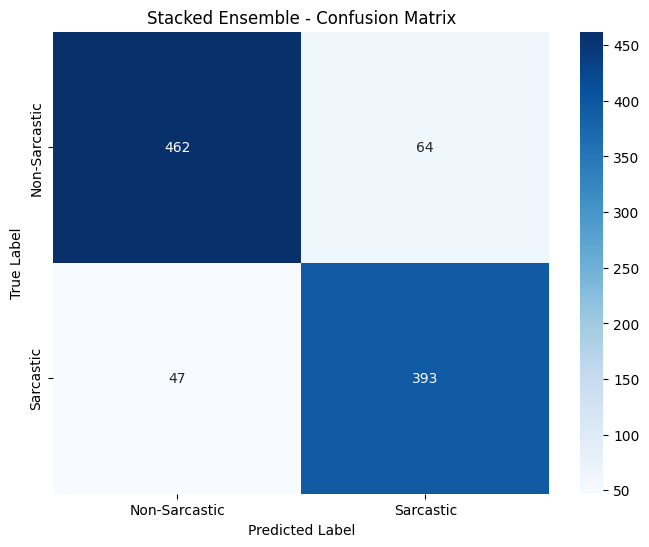

In [57]:
# ================================================================================
# Step 5: Final Evaluation on Test Set
# ================================================================================
print("="*80)
print("FINAL EVALUATION: STACKING ENSEMBLE ON TEST SET")
print("="*80)

# Get predictions from both base models on TEST SET
print("\n Getting base model predictions on test set...")

# CharCNN predictions (test)
charcnn_test_probs = charcnn_model.predict(X_test_char, verbose=0).flatten()
print(f"  CharCNN: {charcnn_test_probs.shape}")

# BiLSTM predictions (test)
bilstm_test_probs = glove_model.predict(X_test_pad, verbose=0).flatten()
print(f"  BiLSTM:  {bilstm_test_probs.shape}")

# Stack predictions as features
X_test_meta = np.column_stack([charcnn_test_probs, bilstm_test_probs])
y_test = test_df['label'].values

print(f"\n Meta-features shape: {X_test_meta.shape}")

# Predict using meta-learner
print("\n Making final predictions with stacked ensemble...")
y_test_pred_stacked = meta_learner.predict(X_test_meta)
y_test_prob_stacked = meta_learner.predict_proba(X_test_meta)[:, 1]

# Calculate metrics
stacked_accuracy = accuracy_score(y_test, y_test_pred_stacked)
stacked_precision = precision_score(y_test, y_test_pred_stacked)
stacked_recall = recall_score(y_test, y_test_pred_stacked)
stacked_f1 = f1_score(y_test, y_test_pred_stacked)

print("\n" + "="*80)
print(" STACKED ENSEMBLE (BiLSTM + CharCNN) - TEST SET PERFORMANCE")
print("="*80)
print(f"  Accuracy:  {stacked_accuracy:.4f} ({stacked_accuracy*100:.2f}%)")
print(f"  Precision: {stacked_precision:.4f}")
print(f"  Recall:    {stacked_recall:.4f}")
print(f"  F1 Score:  {stacked_f1:.4f}")

print("\n Detailed Classification Report:")
print(classification_report(y_test, y_test_pred_stacked, 
                          target_names=['Non-Sarcastic', 'Sarcastic']))

# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred_stacked)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-Sarcastic', 'Sarcastic'],
            yticklabels=['Non-Sarcastic', 'Sarcastic'])
plt.title('Stacked Ensemble - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print("\n" + "="*80)


In [68]:
# ================================================================================
# Step 6: Compare Individual Models vs Stacking Ensemble
# ================================================================================
print("="*80)
print("MODEL COMPARISON: INDIVIDUAL vs STACKING ENSEMBLE")
print("="*80)

# Evaluate individual models on test set
# CharCNN alone
charcnn_pred = (charcnn_test_probs > 0.5).astype(int)
charcnn_acc = accuracy_score(y_test, charcnn_pred)
charcnn_f1 = f1_score(y_test, charcnn_pred)

# BiLSTM alone
bilstm_pred = (bilstm_test_probs > 0.5).astype(int)
bilstm_acc = accuracy_score(y_test, bilstm_pred)
bilstm_f1 = f1_score(y_test, bilstm_pred)

# Create comparison table
comparison_data = {
    'Model': [
        'CharCNN (Character-level CNN)',
        'BiLSTM+GloVe (Word-level)',
        ' STACKING ENSEMBLE'
    ],
    'Accuracy': [
        f'{charcnn_acc:.4f} ({charcnn_acc*100:.2f}%)',
        f'{bilstm_acc:.4f} ({bilstm_acc*100:.2f}%)',
        f'{stacked_accuracy:.4f} ({stacked_accuracy*100:.2f}%)'
    ],
    'F1 Score': [
        f'{charcnn_f1:.4f}',
        f'{bilstm_f1:.4f}',
        f'{stacked_f1:.4f}'
    ],
    'Precision': [
        f'{precision_score(y_test, charcnn_pred):.4f}',
        f'{precision_score(y_test, bilstm_pred):.4f}',
        f'{stacked_precision:.4f}'
    ],
    'Recall': [
        f'{recall_score(y_test, charcnn_pred):.4f}',
        f'{recall_score(y_test, bilstm_pred):.4f}',
        f'{stacked_recall:.4f}'
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n COMPREHENSIVE MODEL COMPARISON:")
print(comparison_df.to_string(index=False))

# Calculate improvements
improvement_over_bilstm = (stacked_accuracy - bilstm_acc) * 100
improvement_over_charcnn = (stacked_accuracy - charcnn_acc) * 100

print("\n" + "="*80)
print(" IMPROVEMENT ANALYSIS")
print("="*80)
print(f"Stacking vs BiLSTM alone:  {improvement_over_bilstm:+.2f} percentage points")
print(f"Stacking vs CharCNN alone: {improvement_over_charcnn:+.2f} percentage points")

if stacked_accuracy > max(bilstm_acc, charcnn_acc):
    print("\n SUCCESS! Stacking ensemble outperforms both individual models!")
    print("   -> The meta-learner successfully learned to combine model strengths")
elif stacked_accuracy >= max(bilstm_acc, charcnn_acc) - 0.01:
    print("\n Stacking matches best individual model (within 1%)")
    print("   -> Provides robustness without sacrificing performance")
else:
    print("\n  Stacking underperforms best individual model")
    print("   -> Consider: more diverse base models or different meta-learner")

# Show which model is stronger
if bilstm_f1 > charcnn_f1:
    print(f"\n Stronger base model: BiLSTM (F1: {bilstm_f1:.4f})")
    print(f"   Weaker base model: CharCNN (F1: {charcnn_f1:.4f})")
else:
    print(f"\n Stronger base model: CharCNN (F1: {charcnn_f1:.4f})")
    print(f"   Weaker base model: BiLSTM (F1: {bilstm_f1:.4f})")

print("\n" + "="*80)


MODEL COMPARISON: INDIVIDUAL vs STACKING ENSEMBLE

 COMPREHENSIVE MODEL COMPARISON:
                        Model        Accuracy F1 Score Precision Recall
CharCNN (Character-level CNN) 0.8427 (84.27%)   0.8311    0.8130 0.8500
    BiLSTM+GloVe (Word-level) 0.8716 (87.16%)   0.8610    0.8496 0.8727
            STACKING ENSEMBLE 0.8851 (88.51%)   0.8763    0.8600 0.8932

 IMPROVEMENT ANALYSIS
Stacking vs BiLSTM alone:  +1.35 percentage points
Stacking vs CharCNN alone: +4.24 percentage points

 SUCCESS! Stacking ensemble outperforms both individual models!
   -> The meta-learner successfully learned to combine model strengths

 Stronger base model: BiLSTM (F1: 0.8610)
   Weaker base model: CharCNN (F1: 0.8311)



In [78]:
# ================================================================================
# Step 7: Save Stacking Ensemble Components
# ================================================================================
print("="*80)
print("SAVING STACKING ENSEMBLE")
print("="*80)

import pickle
from pathlib import Path

model_dir = Path('models')
model_dir.mkdir(exist_ok=True)

# Save CharCNN model
charcnn_model.save('models/charcnn_model.h5')
print(" CharCNN model saved: models/charcnn_model.h5")

# Save character tokenizer
with open('models/char_tokenizer.pkl', 'wb') as f:
    pickle.dump(char_tokenizer, f)
print(" Character tokenizer saved: models/char_tokenizer.pkl")

# Save meta-learner (LR stacker)
with open('models/meta_learner.pkl', 'wb') as f:
    pickle.dump(meta_learner, f)
print(" Meta-learner saved: models/meta_learner.pkl")

# BiLSTM+GloVe and word tokenizer should already be saved
print(" BiLSTM+GloVe already saved: models/final_glove_bilstm.h5")
print(" Word tokenizer already saved: models/tokenizer.pkl")

# Save stacking configuration
stacking_config = {
    'model_type': 'stacking_ensemble',
    'base_models': ['CharCNN', 'BiLSTM+GloVe'],
    'meta_learner': 'Logistic Regression',
    'test_accuracy': float(stacked_accuracy),
    'test_f1': float(stacked_f1),
    'test_precision': float(stacked_precision),
    'test_recall': float(stacked_recall),
    'charcnn_accuracy': float(charcnn_acc),
    'charcnn_f1': float(charcnn_f1),
    'bilstm_accuracy': float(bilstm_acc),
    'bilstm_f1': float(bilstm_f1),
    'meta_learner_coef': meta_learner.coef_[0].tolist(),
    'meta_learner_intercept': float(meta_learner.intercept_[0]),
    'max_chars': MAX_CHARS,
    'max_words_len': 100  # BiLSTM max length
}

with open('models/stacking_config.pkl', 'wb') as f:
    pickle.dump(stacking_config, f)
print(" Stacking config saved: models/stacking_config.pkl")

print("\n" + "="*80)
print(" STACKING ENSEMBLE COMPONENTS")
print("="*80)
print("Required files for inference:")
print("  1. models/charcnn_model.h5          (CharCNN weights)")
print("  2. models/char_tokenizer.pkl        (Character tokenizer)")
print("  3. models/final_glove_bilstm.h5     (BiLSTM weights)")
print("  4. models/tokenizer.pkl             (Word tokenizer)")
print("  5. models/meta_learner.pkl          (LR stacker)")
print("  6. models/stacking_config.pkl       (Configuration)")
print("\n All components saved successfully!")
print("="*80)


SAVING STACKING ENSEMBLE
 CharCNN model saved: models/charcnn_model.h5
 Character tokenizer saved: models/char_tokenizer.pkl
 Meta-learner saved: models/meta_learner.pkl
 BiLSTM+GloVe already saved: models/final_glove_bilstm.h5
 Word tokenizer already saved: models/tokenizer.pkl
 Stacking config saved: models/stacking_config.pkl

 STACKING ENSEMBLE COMPONENTS
Required files for inference:
  1. models/charcnn_model.h5          (CharCNN weights)
  2. models/char_tokenizer.pkl        (Character tokenizer)
  3. models/final_glove_bilstm.h5     (BiLSTM weights)
  4. models/tokenizer.pkl             (Word tokenizer)
  5. models/meta_learner.pkl          (LR stacker)
  6. models/stacking_config.pkl       (Configuration)

 All components saved successfully!


In [79]:
# ================================================================================
# Fix: Save Missing Files (tokenizer.pkl and final_glove_bilstm.h5)
# ================================================================================
print("="*80)
print("SAVING MISSING FILES")
print("="*80)

import pickle

# Save word tokenizer (for BiLSTM)
with open('models/tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print(" Word tokenizer saved: models/tokenizer.pkl")

# Save BiLSTM+GloVe model
glove_model.save('models/final_glove_bilstm.h5')
print(" BiLSTM+GloVe model saved: models/final_glove_bilstm.h5")

print("\n" + "="*80)
print("ALL 6 REQUIRED FILES NOW COMPLETE")
print("="*80)
print("You can now run:")
print("  python predict_sarcasm.py --input test.csv --output predictions.csv")
print("="*80)



SAVING MISSING FILES
 Word tokenizer saved: models/tokenizer.pkl
 BiLSTM+GloVe model saved: models/final_glove_bilstm.h5

ALL 6 REQUIRED FILES NOW COMPLETE
You can now run:
  python predict_sarcasm.py --input test.csv --output predictions.csv
